Normal Reconstruction Error: 0.013599919155240059
Anomaly Reconstruction Error: 0.9391403198242188
Generated output images: k1.png - k4.png


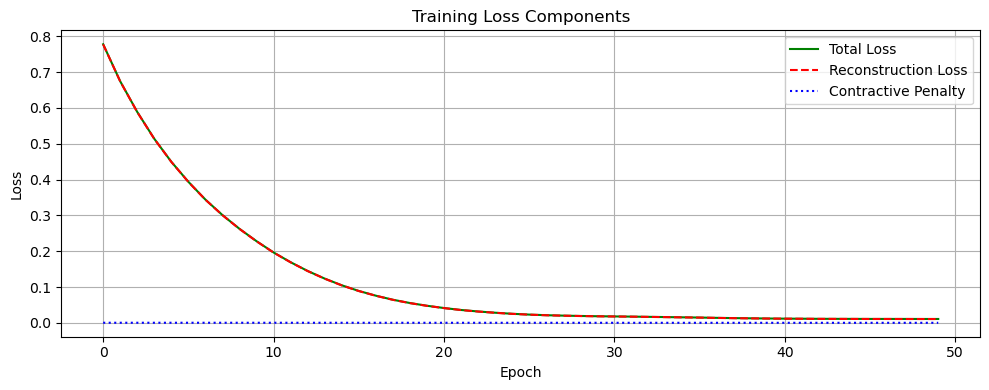

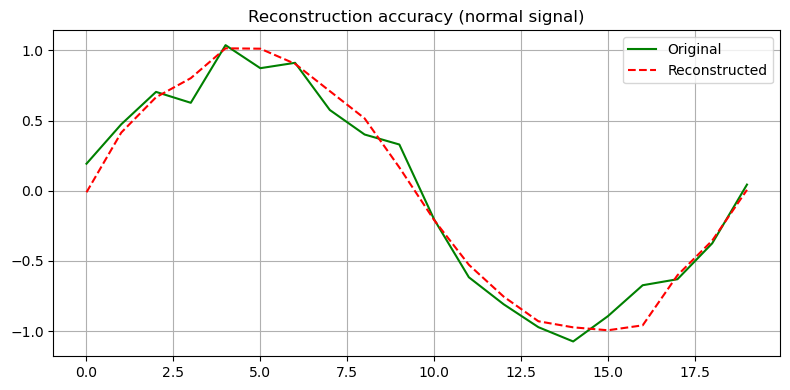

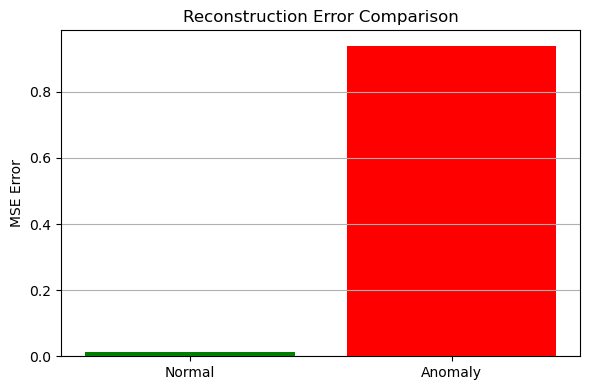

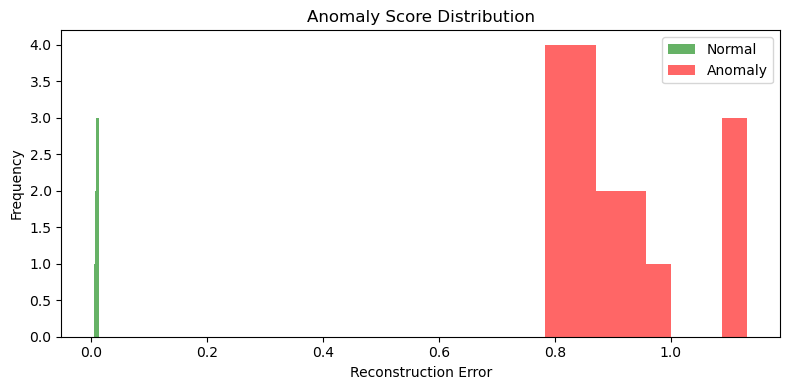

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Generation
torch.manual_seed(42)
t = torch.linspace(0, 2*np.pi, 20)
clean_data = torch.stack([torch.sin(t) for _ in range(16)])
train_data = clean_data + 0.1 * torch.randn_like(clean_data)

# 2. Model definition
class HybridAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(HybridAE, self).__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        h_logit = self.encoder(x)
        h = self.sigmoid(h_logit)
        rec = self.decoder(h)
        return h, rec

model = HybridAE(20, 10)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()
lam = 1e-4

loss_values, rec_values, cae_values = [], [], []

# 3. Training Loop
for epoch in range(50):
    noisy_input = train_data + 0.05 * torch.randn_like(train_data)
    h, rec = model(noisy_input)
    loss_rec = criterion(rec, train_data)
    W = model.encoder.weight
    dh = h * (1 - h)
    contractive_loss = torch.sum(dh**2 * torch.sum(W**2, dim=1))
    loss = loss_rec + lam * contractive_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_values.append(loss.item())
    rec_values.append(loss_rec.item())
    cae_values.append((lam * contractive_loss).item())

# 4. Visualization
plt.figure(figsize=(10,4))
plt.plot(loss_values, 'g-', label='Total Loss')
plt.plot(rec_values, 'r--', label='Reconstruction Loss')
plt.plot(cae_values, 'b:', label='Contractive Penalty')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("k1.png")

# Reconstruction Example
plt.figure(figsize=(8,4))
idx = 0
with torch.no_grad():
    _, reconstructed = model(train_data[idx:idx+1])
plt.plot(train_data[idx].numpy(), 'g-', label='Original')
plt.plot(reconstructed.numpy().flatten(), 'r--', label='Reconstructed')
plt.title('Reconstruction accuracy (normal signal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("k2.png")

# Anomaly Detection
anomaly_sample = torch.rand(1, 20)
with torch.no_grad():
    _, anomaly_rec = model(anomaly_sample)
normal_score = criterion(reconstructed, train_data[idx:idx+1]).item()
anomaly_score = criterion(anomaly_rec, anomaly_sample).item()

scores = [normal_score, anomaly_score]
labels = ['Normal', 'Anomaly']
plt.figure(figsize=(6,4))
plt.bar(labels, scores, color=['green', 'red'])
plt.title('Reconstruction Error Comparison')
plt.ylabel('MSE Error')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("k3.png")

# Anomaly Score Histogram
noise_set = torch.rand(16, 20)
with torch.no_grad():
    scores_normal = [criterion(model(train_data[i:i+1])[1], train_data[i:i+1]).item() for i in range(16)]
    scores_anomaly = [criterion(model(noise_set[i:i+1])[1], noise_set[i:i+1]).item() for i in range(16)]

plt.figure(figsize=(8,4))
plt.hist(scores_normal, bins=8, color='green', alpha=0.6, label='Normal')
plt.hist(scores_anomaly, bins=8, color='red', alpha=0.6, label='Anomaly')
plt.title('Anomaly Score Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig("k4.png")

print("Normal Reconstruction Error:", normal_score)
print("Anomaly Reconstruction Error:", anomaly_score)
print("Generated output images: k1.png - k4.png")
